# 1 - Import des données

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Patrimoine_Arbore_Nettoye.csv')
data.head()

,clc_quartier,clc_secteur,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,fk_port,fk_pied,fk_situation,...,dte_plantation,age_estim,fk_prec_estim,dte_abattage,fk_nomtech,villeca,feuillage,remarquable,long,lat
0,Quartier du Centre-Ville,Boulevard Richelieu,1200,300.0,100,SUPPRIMÉ,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,2015/07/01 00:00:00+00,RAS,VILLE,Non renseigné,Non,3.282540,49.850458
1,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,ABATTU,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.290521,49.840654
2,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,SUPPRIMÉ,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.290460,49.840756
3,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,SUPPRIMÉ,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.290568,49.840783
4,Quartier du Centre-Ville,Boulevard Léon Blum,1200,300.0,100,ABATTU,Non renseigné,Non renseigné,Non renseigné,Alignement,...,Non renseigné,30,10.0,Non renseigné,RAS,VILLE,Non renseigné,Non,3.293178,49.841441


## Récupérer données d'intérêt

In [35]:
data_num = data[['haut_tot', 'tronc_diam', 'haut_tronc', 'age_estim', 'fk_nomtech']]
# On extrait les 3 premières lettres du nom technique
data_num['genre'] = data_num['fk_nomtech'].str[:3]

# On affecte des noms en fonction des initiales
mapping_noms = {
    'TIL': 'Tilleul',
    'PLA': 'Platane',
    'PIN': 'Pin',
    'BET': 'Bouleau',
    'ACE': 'Érable',
    'FAG': 'Hêtre',
    'PRU': 'Prunus',
    'CAR': 'Charme',
    'QUE': 'Chêne'
}

# Application du mapping et gestion des "Autres"
data_num['genre_label'] = data_num['genre'].map(mapping_noms).fillna('Autres')
data_num.drop(columns=['fk_nomtech', 'genre'], inplace=True)
data_num.head()


# Transformation catégories puis récupération des codes
data_num['genre_id'] = data_num['genre_label'].astype('category').cat.codes
# Afficher la correspondance des espèces d'arbres
correspondance = dict(enumerate(data_num['genre_label'].astype('category').cat.categories))
print("Table de correspondance :", correspondance)
data_num.drop(columns=['genre_label'], inplace=True)
data_num.head()



Table de correspondance : {0: 'Autres', 1: 'Bouleau', 2: 'Charme', 3: 'Chêne', 4: 'Hêtre', 5: 'Pin', 6: 'Platane', 7: 'Prunus', 8: 'Tilleul', 9: 'Érable'}


/tmp/ipykernel_24833/1669720676.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_num['genre'] = data_num['fk_nomtech'].str[:3]
/tmp/ipykernel_24833/1669720676.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_num['genre_label'] = data_num['genre'].map(mapping_noms).fillna('Autres')
/tmp/ipykernel_24833/1669720676.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

,haut_tot,tronc_diam,haut_tronc,age_estim,genre_id
0,1200,100,300.0,30,0
1,1200,100,300.0,30,0
2,1200,100,300.0,30,0
3,1200,100,300.0,30,0
4,1200,100,300.0,30,0


Matrice de corrélation :

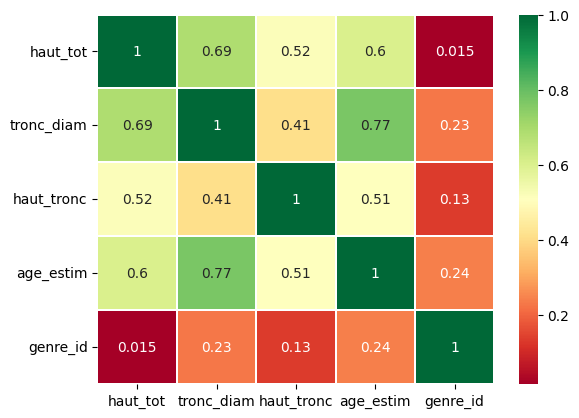

In [36]:
data_num.corr()
import seaborn as sns
sns.heatmap(data_num.corr(), annot=True, cmap='RdYlGn', linewidths=0.2)
plt.show()

On choisit de garder les paramètres numériques tels que haut_tot, haut_tronc et tronc_diam ainsi que le genre (espèce de l'arbre)

In [37]:
data_features = data_num[['haut_tot', 'haut_tronc', 'tronc_diam', 'genre_id']]
data_target = data_num[['age_estim']]

Séparer en deux sets : entrainement et test (20% de test)

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data_features, data_target, test_size=0.2)

## Prétraitement des données

Nous allons utiliser un `StandardScaler` pour normaliser les caractéristiques numériques -> Modèle n'attribue pas une importance disproportionnée aux caractéristiques ayant des valeurs plus grandes.

In [39]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train = x_train_scaled
x_test = x_test_scaled

joblib.dump(scaler, 'standard_scaler.pkl')
print("StandardScaler sauvegardé : 'standard_scaler.pkl'")

StandardScaler sauvegardé : 'standard_scaler.pkl'


# 2 - Algorithme d'apprentissage supervisé

## Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression

# 1. Initialisation et entraînement du modèle Linéaire
lr_model = LinearRegression()
lr_model.fit(x_train, y_train.values.ravel())

# 2. Prédictions
y_pred_lr = lr_model.predict(x_test)

# 3. Calcul des métriques pour la Régression Linéaire
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("Résultats Régression Linéaire :")
print(f'MAE: {mae_lr:.2f}')
print(f'MSE: {mse_lr:.2f}')
print(f'R2 Score: {r2_lr:.4f}')
print(f'RMSE: {rmse_lr:.2f}')

--- Résultats Régression Linéaire ---
MAE: 8.29
MSE: 134.91
R2 Score: 0.6174
RMSE: 11.61


## Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn import tree

model = RandomForestRegressor()
model.fit(x_train, y_train)

y_predict = model.predict(x_test)

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
r2_score_val = r2_score(y_test, y_predict)
rmse = np.sqrt(mse)

print('mae', mae)
print('mse', mse)
print('r2_score', r2_score_val)
print('rmse', rmse)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


mae 5.4366222853997925
mse 84.80124033318953
r2_score 0.7594906658822185
rmse 9.208758892119477


En moyenne, 10-11 ans d'écart avec la réalité

## Chercher les meilleurs hyperparamètres pour le modèle

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log', None],
    'min_samples_split': [2, 5],
    'max_depth': [None, 15, 30],
    'min_samples_leaf': [1, 2, 4],
}


rfr = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rfr, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error')

grid_search.fit(x_train, y_train.values.ravel())

print("Meilleurs paramètres : ", grid_search.best_params_)
print("Meilleure MAE : ", -grid_search.best_score_)

best_rfr_model = grid_search.best_estimator_
y_predict_best = best_rfr_model.predict(x_test)

mae_best = mean_absolute_error(y_test, y_predict_best)
mse_best = mean_squared_error(y_test, y_predict_best)
r2_score_best = r2_score(y_test, y_predict_best)
rmse_best = np.sqrt(mse_best)

print('\nMetrics pour meilleur modèle:')
print('mae:', mae_best)
print('mse:', mse_best)
print('r2_score:', r2_score_best)
print('rmse:', rmse_best)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
162 fits failed out of a total of 486.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
54 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", 

Meilleurs paramètres :  {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Meilleure MAE :  5.738022518258465

Metrics pour meilleur modèle:
mae: 5.282863113325283
mse: 77.36008248019552
r2_score: 0.780594931730892
rmse: 8.795458059714429


# 3 - Evaluation des résultats

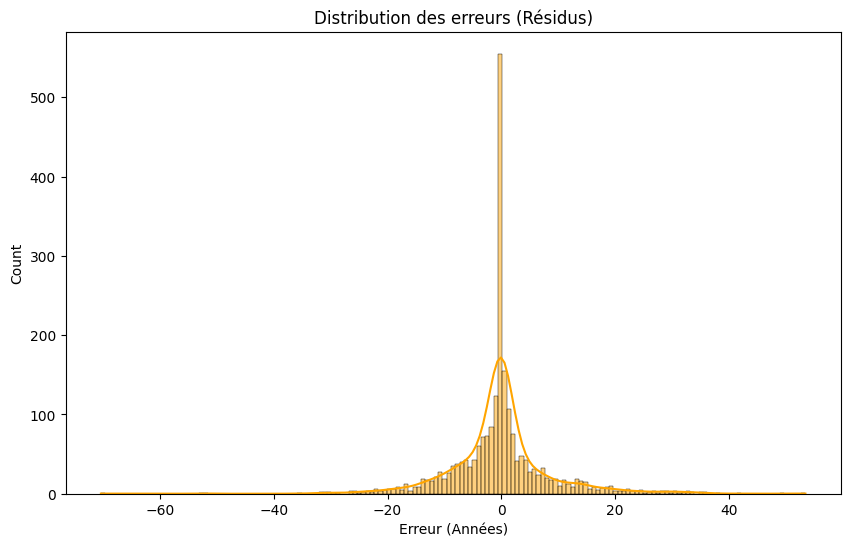

In [45]:
residus = y_test.values.ravel() - y_predict_best

plt.figure(figsize=(10, 6))
sns.histplot(residus, kde=True, color='orange')
plt.title('Distribution des erreurs (Résidus)')
plt.xlabel('Erreur (Années)')
plt.show()

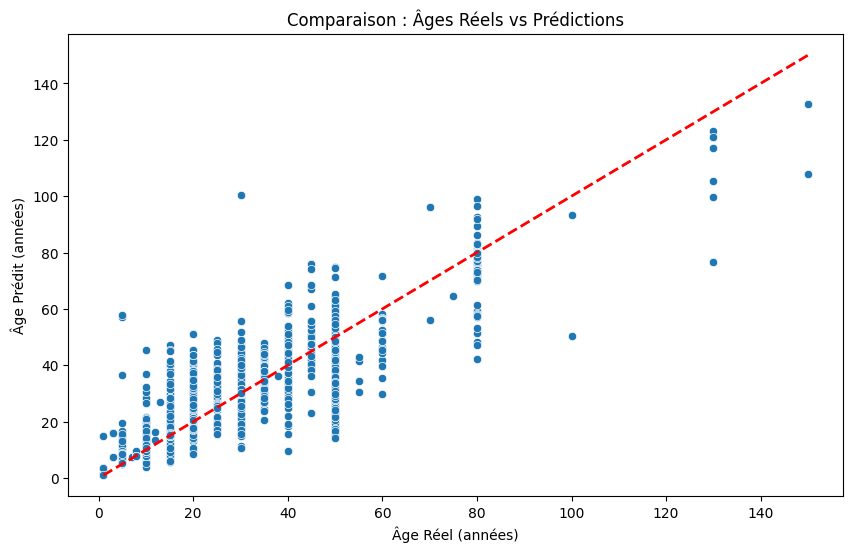

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test.values.ravel(), y=y_predict_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Âge Réel (années)')
plt.ylabel('Âge Prédit (années)')
plt.title('Comparaison : Âges Réels vs Prédictions')
plt.show()

# 4 - Récupération du meilleur modèle

In [47]:
import joblib
# Comparaison finale entre la régression linéaire et le random forest regressor pour sauvegarde
if r2_score_best > r2_lr:
    print(f"Le Random Forest Regressor est meilleur (R2: {r2_score_best:.4f} vs {r2_lr:.4f})")
    joblib.dump(best_rfr_model, 'meilleur_modele_arbre.pkl')
else:
    print(f"La Régression Linéaire est meilleure (R2: {r2_lr:.4f} vs {r2_score_best:.4f})")
    joblib.dump(lr_model, 'meilleur_modele_arbre.pkl')

Le Random Forest est meilleur (R2: 0.7806 vs 0.6174)
